# Answer these Questions


 * Can we use total length to predict a possum's head length?
* Which possum body dimensions are most  correlated with age and sex?
* Can we classify a possum's sex by its body dimensions and location?
* Can we predict a possum's trapping location from its body dimensions?



In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("possum.csv")
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [ ]:
df = df.dropna()


#Can we use total length to predict a possum's head length?

## Linear Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score


X = df["totlngth"].values.reshape(-1, 1)
Y = df["hdlngth"].values

model = LinearRegression()
model.fit(X, Y)

LinearRegression()

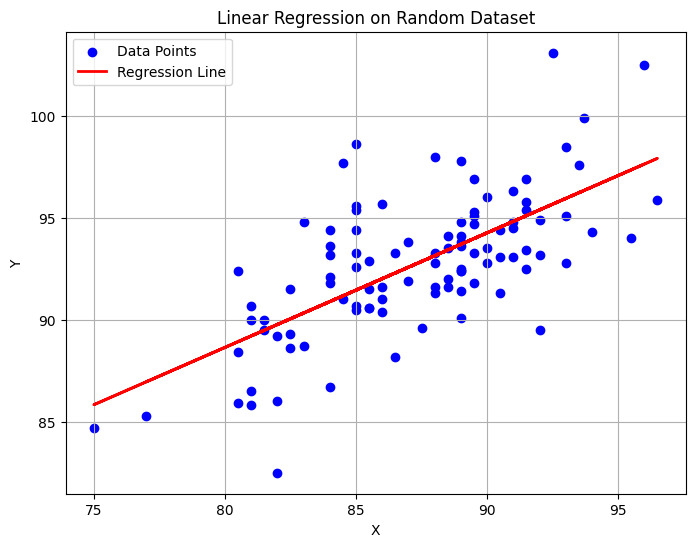

In [ ]:
Y_pred = model.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
r2_score(Y, Y_pred)

0.4494381774703834

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression uses continuous metrics, not accuracy
mse = mean_squared_error(Y, Y_pred)
mae = mean_absolute_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

R-squared: 0.4494
Mean Squared Error: 6.7492
Mean Absolute Error: 1.9973


#Logistic Regression




In [ ]:
from sklearn.metrics import accuracy_score

X = df["totlngth"].values.reshape(-1, 1)
Y = df["hdlngth"].values

# Logistic regression needs discrete classes.
median_hdlngth = np.median(Y)
Y_class = (Y > median_hdlngth).astype(int)

model = LogisticRegression()
model.fit(X, Y_class)
print(f"Model fitted with classes: {model.classes_}")

# Evaluate using accuracy instead of r2_score
Y_pred_class = model.predict(X)
accuracy = accuracy_score(Y_class, Y_pred_class)
print(f"Accuracy: {accuracy:.4f}")

Model fitted with classes: [0 1]
Accuracy: 0.7030


#Report


Since logistic regression requires a discrete number of classes, it's not possibile to do unless I make the class discrete. Overall, Linear Regression was the way to go with a r-square of 47%

#Which possum body dimensions are most  correlated with age and sex?


In [ ]:
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [ ]:
df.columns[-9]

'hdlngth'

###Linear Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

r_scores = []

for col in df.columns[-9:]:
  # Head Length
  X = df[['age']].values
  catFeat = ['sex']
  t = pd.get_dummies(df[catFeat], columns=catFeat, drop_first=True)
  X = np.concatenate((X, t), axis=1)
  Y = df[col]
  model = LinearRegression()
  model.fit(X, Y)
  print(f"{col} r^2 is {r2_score(Y, model.predict(X))}")
  r_scores.append(r2_score(Y, model.predict(X)))



hdlngth r^2 is 0.12761405323050035
skullw r^2 is 0.09620248012860555
totlngth r^2 is 0.09079540801901254
taill r^2 is 0.014978117966764959
footlgth r^2 is 0.03284319005323855
earconch r^2 is 0.021305314694991195
eye r^2 is 0.10477167019930966
chest r^2 is 0.12197832202517345
belly r^2 is 0.13553119152625592


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Drop rows with NaNs in relevant columns to avoid fitting errors
temp_df = df.dropna(subset=['age', 'sex'] + list(df.columns[-9:]))

for col in temp_df.columns[-9:]:
  X = temp_df[['age']].values
  catFeat = ['sex']
  t = pd.get_dummies(temp_df[catFeat], columns=catFeat, drop_first=True)
  X = np.concatenate((X, t), axis=1)

  Y = temp_df[col].values
  # Convert continuous target into discrete classes (above/below median)
  median_val = np.median(Y)
  Y_class_col = (Y > median_val).astype(int)

  model = LogisticRegression()
  model.fit(X, Y_class_col)

  Y_pred_class = model.predict(X)
  accuracy = accuracy_score(Y_class_col, Y_pred_class)
  print(f"Accuracy for {col}: {accuracy:.4f}")

Accuracy for hdlngth: 0.6436
Accuracy for skullw: 0.6634
Accuracy for totlngth: 0.6238
Accuracy for taill: 0.5545
Accuracy for footlgth: 0.5743
Accuracy for earconch: 0.6040
Accuracy for eye: 0.6337
Accuracy for chest: 0.6436
Accuracy for belly: 0.6634


Report

Again Logistic is not possible since the number of classes is not discrete, Making Linear Regression the model to use for a question like this.

#Can we classify a possum's sex by its body dimensions and location?

In [ ]:
df.dropna(inplace=True)
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



X = df.drop(columns=['case', 'site', 'Pop', 'sex', 'age']).values
catFeat = ["Pop"]
t = pd.get_dummies(df[catFeat], columns=catFeat, drop_first=True)
X = np.concatenate((X, t), axis=1)
#Y = df["sex"]

catFeat = ["sex"]
Y = pd.get_dummies(df[catFeat], columns=catFeat, drop_first=True)


model = LinearRegression()
model.fit(X, Y)


LinearRegression()

In [ ]:
Y_pred = model.predict(X)

In [ ]:
r2_score(Y, Y_pred)

0.21254177786601447

#Logistic Regresion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = df.drop(columns=['case', 'site', 'Pop', 'sex', 'age']).values
catFeat = ["Pop"]
t = pd.get_dummies(df[catFeat], columns=catFeat, drop_first=True)
X = np.concatenate((X, t), axis=1)

catFeat = ["sex"]
# Use .values.ravel() to fix the DataConversionWarning
Y = pd.get_dummies(df[catFeat], columns=catFeat, drop_first=True).values.ravel()

model = LogisticRegression(max_iter=10000)
model.fit(X, Y)

LogisticRegression(max_iter=10000)

In [ ]:
Y_pred = model.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y, Y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7030


#Report

For classifying a possum's sex (a discrete variable), Logistic Regression is the more appropriate model. The Logistic Regression model achieved an accuracy of 0.7030, indicating that it correctly classified the sex for about 70.3% of the possums. While Linear Regression can be applied to a binary target (treating it as a continuous variable), its R-squared of 0.2125 suggests it explains only about 21.25% of the variance in the 'sex' variable, and its use is generally less suitable for classification tasks compared to Logistic Regression.

#Can we predict a possum's trapping location from its body dimensions?

In [ ]:
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



X = df.drop(columns=['case', 'site', 'Pop', 'sex', 'age']).values
Y = df["site"]


model = LinearRegression()
model.fit(X, Y)


LinearRegression()

In [ ]:
Y_pred = model.predict(X)

In [ ]:
r2_score(Y, Y_pred)

0.8134103872802028

#Logistic Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['case', 'site', 'Pop', 'sex', 'age']).values
Y = df["site"]

# Scale the data to fix the ConvergenceWarning
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=10000)
model.fit(X_scaled, Y)

LogisticRegression(max_iter=10000)

In [ ]:
Y_pred = model.predict(X_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y, Y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8218


#Report

For predicting a possum's trapping location ('site' is a categorical variable), Logistic Regression is the more appropriate model for classification. The Logistic Regression model achieved an accuracy of 0.8218, meaning it correctly predicted the trapping site for approximately 82.18% of the possums. In contrast, Linear Regression, which is designed for continuous target variables, had an R-squared of 0.8134. While this R-squared value is high, accuracy is the metric for evaluating classification tasks, making Logistic Regression the more suitable and effective model for this question.